In [181]:
print("Hello Shubham")

Hello Shubham


In [182]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [183]:
conn=sqlite3.connect("../Dataset/flights.db")
df=pd.read_sql_query("SELECT * From flights",con=conn)
df.head(5)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [184]:
df.shape

(300153, 11)

In [185]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   flight            300153 non-null  str    
 2   source_city       300153 non-null  str    
 3   departure_time    300153 non-null  str    
 4   stops             300153 non-null  str    
 5   arrival_time      300153 non-null  str    
 6   destination_city  300153 non-null  str    
 7   class             300153 non-null  str    
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 25.2 MB


In [186]:
df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [187]:
df.duplicated().sum()

np.int64(0)

In [188]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [189]:
for i in df.columns:
    if df[i].dtype!=int and df[i].dtype!=float:
        print(i,"---->",df[i].unique())
        print("---------------------------------------")

airline ----> <StringArray>
['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo', 'Air_India']
Length: 6, dtype: str
---------------------------------------
flight ----> <StringArray>
['SG-8709', 'SG-8157',  'I5-764',  'UK-995',  'UK-963',  'UK-945',  'UK-927',
  'UK-951',  'G8-334',  'G8-336',
 ...
  '6E-804', '6E-7183', 'SG-6017', '6E-7208', '6E-7252', '6E-7141',  '6E-557',
 '6E-7127', '6E-7259',  'AI-433']
Length: 1561, dtype: str
---------------------------------------
source_city ----> <StringArray>
['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
Length: 6, dtype: str
---------------------------------------
departure_time ----> <StringArray>
['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night', 'Late_Night']
Length: 6, dtype: str
---------------------------------------
stops ----> <StringArray>
['zero', 'one', 'two_or_more']
Length: 3, dtype: str
---------------------------------------
arrival_time ----> <StringArray>
['Night', 'Morning', 'Early_Morn

In [190]:
df.drop(columns=['flight'], inplace=True)

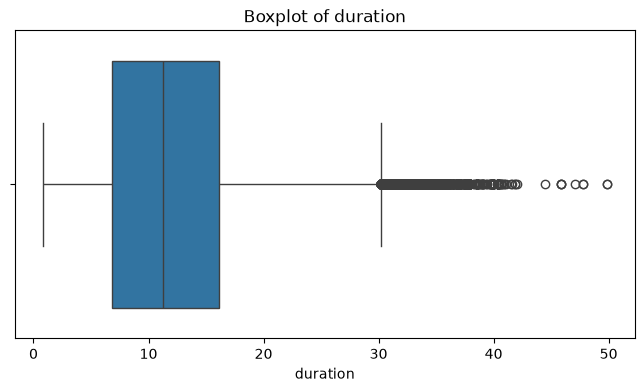

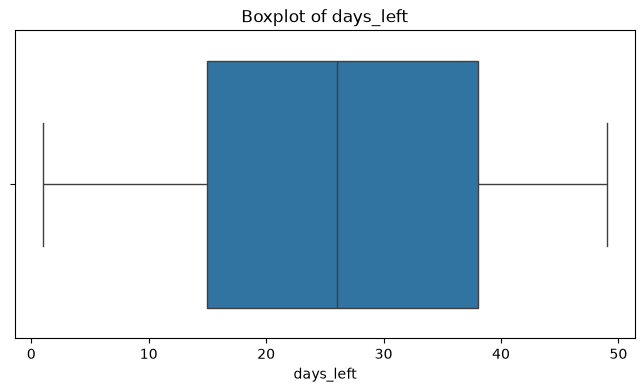

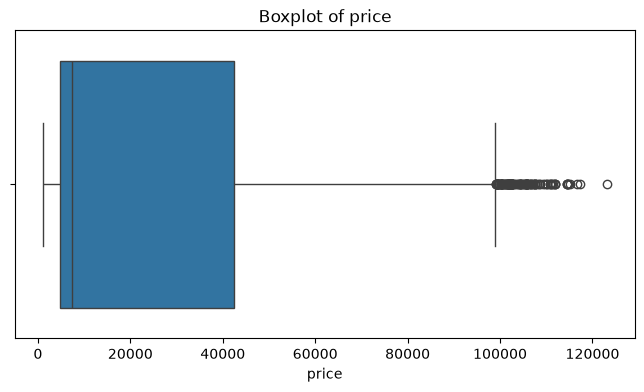

In [191]:
num_cols = ['duration', 'days_left', 'price']

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [192]:
df['stops'].unique()

<StringArray>
['zero', 'one', 'two_or_more']
Length: 3, dtype: str

In [193]:
stop_map = {
    'zero': 0,
    'one': 1,
    'two_or_more': 2
}

df['stops'] = df['stops'].map(stop_map)
df['stops'].unique()

array([0, 1, 2])

In [194]:
df['class'].unique()

<StringArray>
['Economy', 'Business']
Length: 2, dtype: str

In [195]:
class_map = {
    'Economy': 0,
    'Business': 1
}

df['class'] = df['class'].map(class_map)
df['class'].unique()

array([0, 1])

In [196]:
X = df.drop('price', axis=1)
y = df['price']

In [197]:
cat_cols = [
    'airline',
    'source_city',
    'departure_time',
    'arrival_time',
    'destination_city'
]

In [198]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            cat_cols
        )
    ],
    remainder='passthrough'
)

In [199]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [200]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (240122, 9)
X_test : (60031, 9)
y_train: (240122,)
y_test : (60031,)


In [201]:
preprocessor.fit(X_train)

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)